# General instructions for all labs

1. To turn in:
 - this python notebook, filled out (10 pts)
 - a *standalone* PDF report that contains all the plots, and the answers to all the discussion questions (10 pts)

2. Use of ChatGPT / CoPilot / etc:
   - Allowed, but you own everything that is generated
   - This means that any part of the solution can be asked in the midterm. It can be as detailed as "What was the batch size you used in training" or specific as "what exactly does masking do in this case?" Any discussion question is also game for a quiz question.
   - If I find AI usage to be excessive. I can individually drag any of you in for a 1-1 meeting, in which I grill you on your code. If it looks like irresponsible copy/pasting, without proper understanding, I reserve the right to drastically lower your grade, or even submit cases to GGAC for ethical review.
  
3. Use of peer collaboration:
   - In general not allowed. (Discussion / comparing answers is ok, but work on actual coding independently.)
   - Exceptions can be made if you all wrote your own training script, but 1. it takes forever to train or 2. you don't have great compute resources. Then you can share a trained model amongst yourself *and declare it on your pdf*. However, the code for training *still must be written by yourself*
     


# Lab 1: Feature extraction and analysis

## The Titanic Dataset

In this lab, we will work with the **Titanic dataset**, a classic benchmark dataset derived from passenger records of the RMS *Titanic*. The goal is to predict whether a passenger **survived** the disaster based on demographic, social, and travel-related information.

The dataset is interesting for several reasons:

* It contains a **mix of feature types**: numerical (e.g., age, fare), categorical (e.g., sex, class, embarkation port), and identifier-like fields (e.g., name, ticket).
* Several features contain **missing values**, forcing us to think carefully about preprocessing rather than assuming clean data.
* Many features are **correlated or grouped** (for example, passenger class, fare, and cabin location), which makes this dataset ideal for studying feature relationships.
* The target variable (survival) is influenced by **social and structural factors**, leading to patterns that are not purely linear or additive.



# Part 1: Loading and Inspecting the Data

We begin by loading the dataset and performing a basic inspection.

```python
# Load Titanic dataset
df = sns.load_dataset("titanic")

print(df.shape)
print(df.head())
print(df.info())
```

These commands serve three different purposes:

* `df.shape` tells us **how many samples and features** are in the dataset.
* `df.head()` shows the **first few rows**, giving us a concrete sense of what individual data points look like.
* `df.info()` summarizes the **data types**, **non-null counts**, and memory usage, which helps identify:

  * which features are numerical vs categorical,
  * which features have missing values,
  * which features may require preprocessing or encoding.

At this stage, we are not trying to build a model or optimize performance. The goal is simply to understand **what kind of data we are working with**.

---

## Part 1 Step 1: stare at the data

Before moving on, take a few minutes to carefully examine the output of the three commands above, as well as other commands that let you scroll through the textual output of the data (no charts yet).

In particular:

* Which features are numerical? Which are categorical?
* Which features contain missing values?
* Which features look potentially redundant or grouped?
* Which features do you *expect* to be predictive of survival, and why?

Write down **an observations or hypotheses** about the dataset based solely on this inspection.
Do not verify them yet — just note what stands out to you.



In [138]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Load Titanic dataset
df = sns.load_dataset("titanic")

print(df.shape)
print(df.head())
print(df.info())

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nul

## Part 1 Step 2: Basic Survival Statistics 

Using the Titanic dataset loaded above, compute the following quantities.

1. Compute the **percentage of survivors** and **non-survivors** in the full dataset.
2. Compute the **percentage of survivors** and **non-survivors**, **separated by sex**.
3. Compute the **percentage of survivors** and **non-survivors**, **separated by passenger class** (`pclass`).

In your report, also paste the commands you used to get there. 

Based on just observing the raw numbers, would you say these features are predictive of the outcome? Why or why not?


In [139]:
# 1. Compute the **percentage of survivors** and **non-survivors** in the full dataset.
p_survived = df['survived'].mean() * 100
p_nonsurvived = (1 - df['survived'].mean()) * 100

# 2. Compute the **percentage of survivors** and **non-survivors**, **separated by sex**.
p_survived_by_sex = df.groupby(['sex'])['survived'].mean() * 100


# 3. Compute the **percentage of survivors** and **non-survivors**, **separated by passenger class** (`pclass`).
p_survived_by_pclass = df.groupby(['pclass'])['survived'].mean() * 100

print(f"Percentage of passengers who survived: {p_survived:.2f}%")
print(f"Percentage of passengers who did not survive: {p_nonsurvived:.2f}%")
print(p_survived_by_sex)
print(p_survived_by_pclass)


Percentage of passengers who survived: 38.38%
Percentage of passengers who did not survive: 61.62%
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64



## Part 1 Step 3: Basic charts

Create a visualization that shows how **survival rate varies jointly with passenger class and gender**.

Specifically:

* Plot **passenger class** (`pclass`) on the x-axis.
* Plot the **average survival rate** (`survived`) on the y-axis.
* Use **gender** (`sex`) to separate groups within each class.

Your plot should clearly display whether the effect of passenger class on survival differs between men and women.

---

## Follow-Up Question (Written Response)

Based on this plot:

* Does visualizing the data help you decide whether **passenger class** and **gender** are useful features for predicting survival?
* Does the plot suggest that these features act **independently**, or that there is an **interaction** between them?




Text(0.5, 1.0, 'Survival Rate by Passenger Class and Sex')

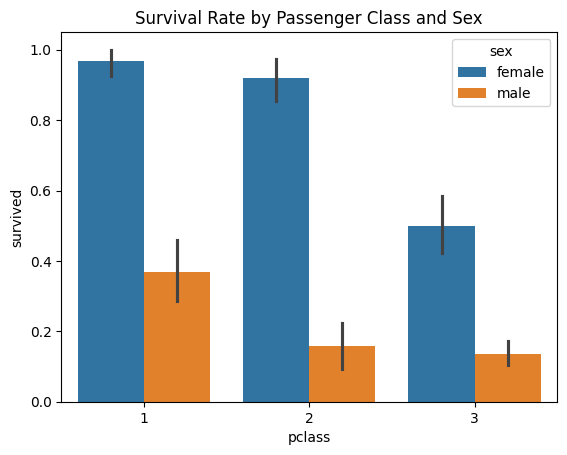

In [140]:
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Survival Rate by Passenger Class and Sex')



## Part 1 Step 4: Examining Correlations Between Numerical Features

In addition to categorical variables, the Titanic dataset contains several **numerical features** that may be related to survival. Before modeling, it is useful to examine how these numerical features relate both to **each other** and to the **target variable**.

### Instructions

Create a correlation matrix for the following numerical features:

* `age`: The age of the passenger in years. 
* `pclass`: The cabin class of the passenger. 
* `sibsp`: The number of siblings or spouses traveling with the passenger. 
* `parch`: The number of parents or children traveling with the passenger. 


Include the target variable `survived` in the correlation matrix.

Visualize the correlations using a heatmap so that both the **strength** and **direction** of correlations are easy to interpret.

---

## Follow-Up Question (Written Response)

Based on the correlation matrix:

* Which numerical features appear most strongly correlated with survival?
* Are there strong correlations **between features themselves** that might indicate redundancy?
* Start to hypothesis, is it possible that these features actually helped **cause** an increase in their survival, or are the effects merely **correlative**? What is the difference between the two? 
 

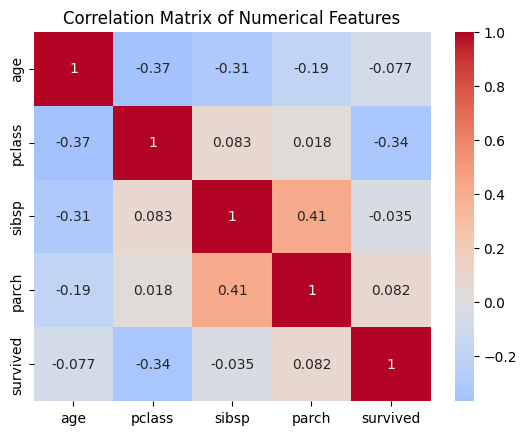

In [141]:
corr_matrix = df[['age', 'pclass', 'sibsp', 'parch', 'survived']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Part 1 Step 5: Exploratory Data Analysis through qualitative evidence

Now your basic exploratory phase is over, and you must find a way to summarize this dataset to your boss, who designs 1800 style boats for daredevil passengers. Your goal is to form a predictive model -- but at this step you are not modeling, only deciding which features are important and why. Scan through each feature
 
* `pclass`: Passenger class (1 = first class, 2 = second class, 3 = third class)
* `sex`: Passenger sex
* `age`: Passenger age in years
* `sibsp`: Number of siblings or spouses traveling with the passenger
* `parch`: Number of parents or children traveling with the passenger
* `fare`: Ticket fare paid by the passenger
* `embarked`: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
* `who`: Passenger category (man, woman, child)
* `adult_male`: Indicator for adult male passengers
* `deck`: Deck level of the cabin (derived from cabin identifier)
* `class`: Textual version of passenger class (First, Second, Third)
* `alone`: Indicator for whether the passenger was traveling alone

and try several different visualization tools and text inspection techniques.

Here are a few plots to pick from: 
1. **Scatter plot**
2. **Box plot**
3. **Violin plot**
4. **Histogram**
5. **Bar plot**
6. **Heatmap**
7. **Pair plot (scatter matrix)**


In your report, include at most 3 plots that inform on the usefulness of each feature, as well as a ranked list of the top 5-10 features. Include a justification of your ranking, using **qualitative evidence** (based on visual inspection).
 


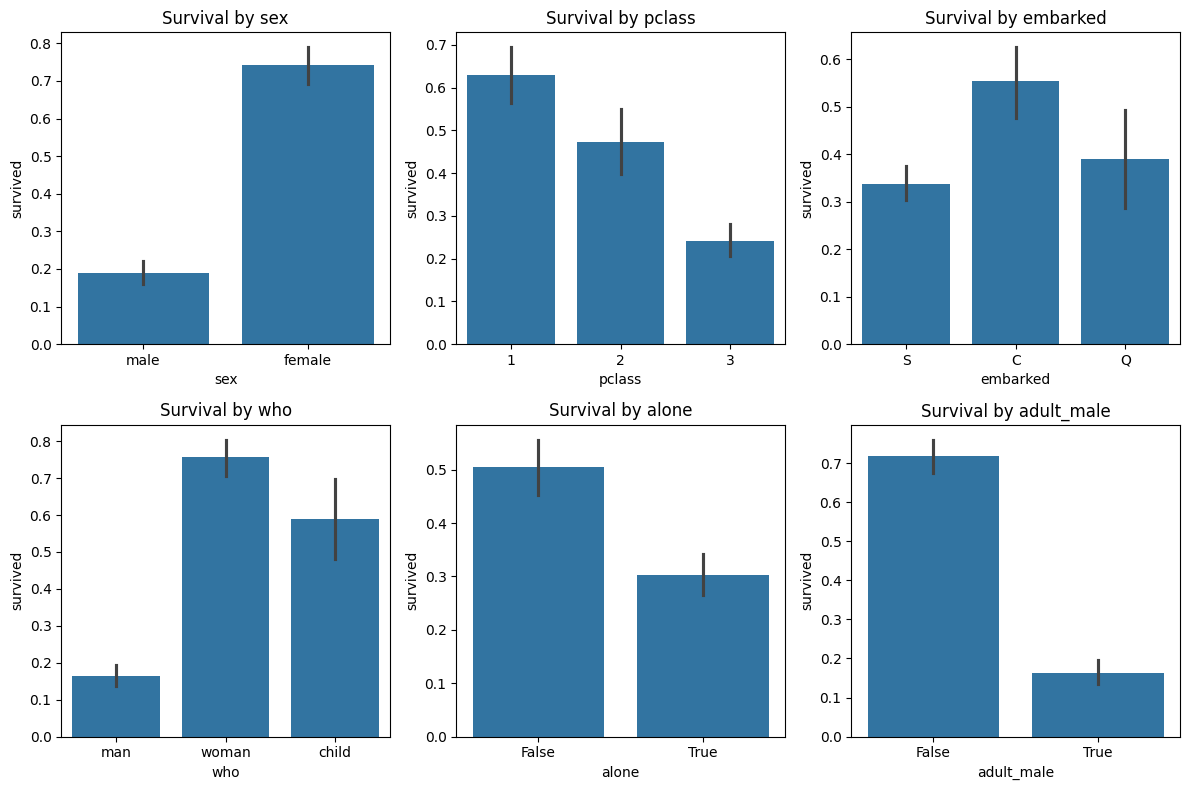

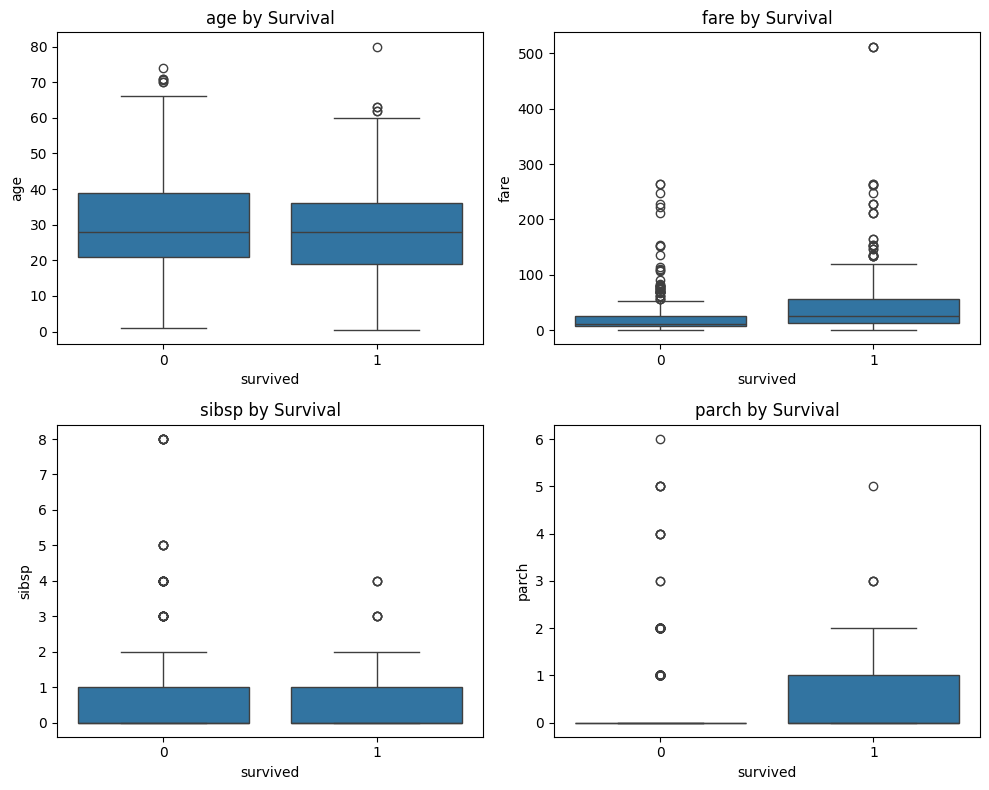

In [142]:
# Plot 1: Categorical features survival rates
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, ['sex', 'pclass', 'embarked', 'who', 'alone', 'adult_male']):
    sns.barplot(x=col, y='survived', data=df, ax=ax)
    ax.set_title(f'Survival by {col}')
plt.tight_layout()
plt.show()

# Plot 2: Numerical features by survival
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ['age', 'fare', 'sibsp', 'parch']):
    sns.boxplot(x='survived', y=col, data=df, ax=ax)
    ax.set_title(f'{col} by Survival')
plt.tight_layout()
plt.show()

## Part 1 Step 6: Exploratory Data Analysis Using Quantitative Evidence

Visual inspection helps build intuition, but quantitative analysis is necessary to make comparisons precise.
In this task, you will analyze feature importance using several quantitative approaches and use the results to reason about **different notions of “importance.”**

---

### One-to-One (Marginal) Correlations

**Task**

Compute the correlation between each individual feature and the target variable (`survived`).

* Compute **Pearson correlation**.
* Compute a **rank-based correlation** (e.g., Spearman).

Rank the features according to each correlation measure.

**Questions**

1. What does it mean for a feature to have a **marginal effect** on the target?
2. What types of relationships are captured by Pearson correlation?
   What additional structure is captured by rank-based correlation?
3. Based on your rankings, which features appear important **marginally**, and which do not?
4. Are there features that appear weak under marginal correlation but may still be useful later?

---

### Many-to-One (Joint) Relationships via Simple Models

**Task**

Choose **one simple model**:

* logistic regression,
* k-nearest neighbors (KNN), or
* decision tree.

Using this model:

* Fit models using **subsets of at most three features**.
* Identify which features or feature combinations lead to the strongest predictive performance.

Report the resulting feature rankings or best-performing subsets.

**Questions**

1. What does it mean for features to have a **joint effect** on the target?
2. How does this approach differ conceptually from one-to-one correlation?
3. Do any features become important only when combined with others?
4. How does your chosen model influence what “joint importance” means?

---

### Leave-One-Out Feature Importance

**Task**

Using the **same model** as in Part 2:

* Fit a model using **all available features**.
* Remove one feature at a time and re-evaluate performance.
* Use the performance change to assign an importance score to each feature.

Rank the features based on this leave-one-out analysis.

**Questions**

1. What does this procedure measure that marginal correlation does not?
2. Is this notion of importance **model-dependent** or **model-agnostic**? Why?
3. Are there features whose importance changes substantially depending on the model?

---


### Reporting Requirements

* Present **three feature-ranking tables**, one for each part.
* Each table must include a caption explaining:

  * what the ranking measures,
  * what notion of importance it reflects,
  * and what its limitations are.
 

Using your results from all three parts, answer the following:

1. **Marginal vs Joint Effects**
   How do your rankings differ between one-to-one correlations and multi-feature models?
   Give at least one example where the distinction matters.

2. **Correlation vs Predictiveness**
   Are the most highly correlated features always the most predictive?
   Use your results to justify your answer.

3. **Model-Dependent vs Model-Agnostic Interpretations**
   Which of your analyses depend on the choice of model, and which do not?
   How does this affect how much you trust each ranking?

Support your answers by explicitly referencing the tables you produced.



In [143]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from itertools import combinations


# Encode categorical variables
df_corr = df.copy()
df_corr['sex_encoded'] = LabelEncoder().fit_transform(df_corr['sex'])
df_corr['alone_encoded'] = df_corr['alone'].astype(int)

emb_dummies = pd.get_dummies(df_corr['embarked'], prefix='embarked') # embark_town is redundant
class_dummies = pd.get_dummies(df_corr['class'], prefix='class') # more informative than pclass alone
deck_dummies  = pd.get_dummies(df_corr['deck'], prefix='deck') # should handle NaNs as all-zero rows, handled pairwise in correlations

df_corr = pd.concat([df_corr, emb_dummies, class_dummies, deck_dummies], axis=1)


# For modeling: parts 2 & 3, drop rows with missing age or embarked in order to train model
df_model = df_corr.dropna(subset=['age', 'embarked'])

features = (
    ['sex_encoded', 'age', 'sibsp', 'parch', 'fare']
    + list(emb_dummies.columns)
    + list(class_dummies.columns)
    + list(deck_dummies.columns)
)

# Part 1: One-to-One (Marginal) Correlations
corr_table = pd.DataFrame({
    'Pearson':  df_corr[features].corrwith(df_corr['survived'], method='pearson'),
    'Spearman': df_corr[features].corrwith(df_corr['survived'], method='spearman')
}).sort_values('Pearson', key=abs, ascending=False).round(4)

display(corr_table)


# Part 2: Many-to-One (Joint) via Simple Model
X = df_model[features]
y = df_model['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
for r in range(1, 4):
    for combo in combinations(features, r):
        feat_subset = list(combo)
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train[feat_subset], y_train)
        acc = model.score(X_test[feat_subset], y_test)
        results.append((feat_subset, acc))

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

display(pd.DataFrame(
    [(', '.join(names), acc) for names, acc in results_sorted[:10]],
    columns=['Features', 'Accuracy']
).round(4))

# Part 3: Leave-One-Out Feature Importance
model_full = LogisticRegression(max_iter=1000, random_state=42)
model_full.fit(X_train, y_train)
baseline_acc = model_full.score(X_test, y_test)

# Groups so that we can leave out related features together (e.g. all one-hot columns for a categorical variable)
feature_groups = {
    'sex':      ['sex_encoded'],
    'age':      ['age'],
    'sibsp':    ['sibsp'],
    'parch':    ['parch'],
    'fare':     ['fare'],
    'embarked': list(emb_dummies.columns),
    'class':    list(class_dummies.columns),
    'deck':     list(deck_dummies.columns),
}

loo_importance = []
for group_name, group_cols in feature_groups.items():
    feat_subset = [f for f in features if f not in group_cols]
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train[feat_subset], y_train)
    acc = model.score(X_test[feat_subset], y_test)
    loo_importance.append({
        'Feature': group_name, 
        'Accuracy w/o': acc, 
        'Importance': baseline_acc - acc
    })
display(pd.DataFrame(loo_importance).sort_values('Importance', ascending=False).reset_index(drop=True).round(4))


,Pearson,Spearman
sex_encoded,-0.5434,-0.5434
class_Third,-0.3223,-0.3223
class_First,0.2859,0.2859
fare,0.2573,0.3237
deck_B,0.1751,0.1751
embarked_C,0.1682,0.1682
embarked_S,-0.1557,-0.1557
deck_D,0.1507,0.1507
deck_E,0.1453,0.1453
deck_C,0.1147,0.1147


,Features,Accuracy
0,"sex_encoded, age, class_Third",0.7832
1,"sex_encoded, parch, fare",0.7622
2,"sex_encoded, fare, class_First",0.7622
3,"sex_encoded, fare, deck_A",0.7622
4,"sex_encoded, fare, deck_B",0.7622
5,"sex_encoded, embarked_C, deck_B",0.7622
6,"sex_encoded, fare",0.7552
7,"sex_encoded, age, fare",0.7552
8,"sex_encoded, sibsp, fare",0.7552
9,"sex_encoded, sibsp, deck_E",0.7552


,Feature,Accuracy w/o,Importance
0,sex,0.6783,0.1189
1,age,0.7063,0.0909
2,class,0.7762,0.0210
3,sibsp,0.7902,0.0070
4,embarked,0.7902,0.0070
5,parch,0.7972,0.0000
6,fare,0.7972,0.0000
7,deck,0.8112,-0.0140


# Part 2: Simple classification baselines

Before performing any feature engineering or sophisticated imputation, we will first
establish **baseline performance** using a small collection of standard classifiers.

The goal of this section is **not** to optimize performance, but to understand how
*difficult* this classification task is using the features in their current form.

Using the features as provided:

- Split the data into **training and test sets**.
- Train each of the following models on the training set:
  1. Logistic regression  
  2. Decision tree  
  3. k-Nearest Neighbors (KNN)  
  4. Two-layer MLP with width 8  
  5. Random forest  

- Evaluate each model on the **test set** and report the **test accuracy**.

- For models that **natively provide feature importance** (logistic regression, decision tree, random forest), also report and briefly interpret the **most influential features**.  This is a pretty strong hint for us to know which features are best.
 



In [144]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use same preprocessed df_model and features from Part 1 Step 6
X = df_model[features]
y = df_model['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'MLP': MLPClassifier(hidden_layer_sizes=(8,8), max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ]) if name in ['Logistic Regression', 'KNN', 'MLP'] else model
    
    pipe.fit(X_train, y_train)
    acc = pipe.score(X_test, y_test)
    
    row = {'Model': name, 'Test Accuracy': round(acc, 4)}
    
    if name == 'Logistic Regression':
        importance = abs(pipe.named_steps['model'].coef_[0])
        # Get top 3 features by absolute coefficient value using argsort to get indices
        top_idx = importance.argsort()[::-1][:3]
        row['Top 3 Features'] = ', '.join([features[i] for i in top_idx])
        row['Importance Scores'] = ', '.join([f"{importance[i]:.3f}" for i in top_idx])
    elif name in ['Decision Tree', 'Random Forest']:
        importance = pipe.feature_importances_
        top_idx = importance.argsort()[::-1][:3]
        row['Top 3 Features'] = ', '.join([features[i] for i in top_idx])
        row['Importance Scores'] = ', '.join([f"{importance[i]:.3f}" for i in top_idx])
    else:
        row['Top 3 Features'] = 'N/A'
        row['Importance Scores'] = 'N/A'
    
    results.append(row)

display(pd.DataFrame(results))

,Model,Test Accuracy,Top 3 Features,Importance Scores
0,Logistic Regression,0.7832,"sex_encoded, age, class_Third","1.321, 0.544, 0.478"
1,Decision Tree,0.7343,"sex_encoded, age, fare","0.308, 0.242, 0.202"
2,KNN,0.7413,N/A,N/A
3,MLP,0.7902,N/A,N/A
4,Random Forest,0.7552,"age, sex_encoded, fare","0.254, 0.250, 0.225"


# Part 3: Missing data

## Missing Data Is Not Uniform

In real datasets, **missing data is rarely random**.
Instead, whether a value is missing often reflects **how the data was collected**, **who was recorded carefully**, and **which groups were less visible**.

In the Titanic dataset, some passenger attributes are missing far more often than others—and crucially, **they are not missing uniformly across passengers**.
Before we decide how to “fix” missing data, we should first **understand its structure**.


---

## Part 3 Step 1: Correlation Between Missingness and Other Features

Rather than immediately imputing missing values, we first ask:

> *When a value is missing, what else about that passenger tends to be different?*
 

### Instructions

1. Identify the features that contain missing values.
2. For each such feature, create a binary indicator that is `1` if the value is missing and `0` otherwise.
3. Encode categorical variables numerically so that relationships can be compared.
4. Compute the correlation between each missingness indicator and the other features.
5. Summarize the results in a **table** showing how missingness relates to passenger attributes (e.g., class, fare, survival).


Which feature is most correlated with data being missing? Any thoughts as to whether this relationship is a *correlation* or a *causation*? Why? Don't be afraid to guess, as long as you make clear it is a guess, not an evidence-based fact.

In [145]:
# 1. Identify missing columns
missing_cols = df.columns[df.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

# 2. Work on df_corr, add who and class dummies as int for numeric cols
who_dummies = pd.get_dummies(df_corr['who'], prefix='who').astype(int)
class_dummies_int = pd.get_dummies(df_corr['class'], prefix='class').astype(int)

# Drop existing bool class dummies from df_corr before concat to avoid duplicates
df_miss = pd.concat([
    df_corr.drop(columns=list(class_dummies.columns)), 
    who_dummies, 
    class_dummies_int
], axis=1)

numeric_cols = df_miss.select_dtypes(include=[np.number]).columns.tolist()

# 3. Create missingness indicators
for col in missing_cols:
    df_miss[col + '_missing'] = df[col].isnull().astype(int)

indicator_cols = [col + '_missing' for col in missing_cols]

# 4. Compute correlation
miss_corr = pd.DataFrame(
    {ind: df_miss[numeric_cols].corrwith(df_miss[ind]) 
     for ind in indicator_cols}
).round(4)

display(miss_corr)

Columns with missing values: ['age', 'embarked', 'deck', 'embark_town']


/home/jusjiang/school/cse519/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jusjiang/school/cse519/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,age_missing,embarked_missing,deck_missing,embark_town_missing
survived,-0.0922,0.0601,-0.3196,0.0601
pclass,0.1729,-0.0743,0.7226,-0.0743
age,NaN,0.0741,-0.2468,0.0741
sibsp,0.0190,-0.0225,0.0393,-0.0225
parch,-0.1241,-0.0225,-0.0383,-0.0225
fare,-0.1007,0.0456,-0.4827,0.0456
sex_encoded,0.0552,-0.0643,0.1426,-0.0643
alone_encoded,0.1513,0.0385,0.1605,0.0385
who_child,-0.1596,-0.0152,0.0544,-0.0152
who_man,0.0996,-0.0584,0.1277,-0.0584


## Part 3 Step 2: Data Imputation on Titanic — Deck

The feature `deck` is **mostly missing**, and its missingness is strongly tied to
the socioeconomic structure of the Titanic passengers.


In particular, deck information is closely related to **passenger class (`pclass`)**
(and, to a lesser extent, fare). This makes `deck` a good candidate for
**structured imputation**, rather than arbitrary filling.

### Task

Your goal is to use the observed data to determine how `deck` relates to other features,
and then use that relationship to **impute missing deck values**.

### Instructions
1. Compute a cross-tabulation of `survived` versus `deck`
   to verify that survival rates differ across decks, and that `deck` is therefore
   an informative feature worth imputing.
2. Restrict the dataset to rows where `deck` is **observed**.
3. Treat `deck` as the **prediction target** and use the remaining features as inputs.
4. Fit a logistic regression model to predict `deck`
5. Evaluate and compare the model's performance.
6. For each model, inspect and report **feature importance** (where available).
7. Use a **cross-tabulation** (`pd.crosstab`) between `deck` and the most important feature
   to verify that the learned relationship is reasonable.

### Discussion Question

Based on your analysis:

- How important is `deck` to survivorship?
- Which feature or features most strongly predict a passenger’s deck when deck is observed?
- How do the model results (accuracy and feature importance) support this conclusion?
- Does the relationship you identified make sense when examined directly in the data
  (e.g., via a cross-tabulation)?
- Why does this make the chosen feature(s) appropriate for imputing missing deck values?


In [146]:
# 1. Cross-tabulation of survived vs deck
survived_deck = pd.crosstab(df['deck'], df['survived'], normalize='index').round(4)
survived_deck.columns = ['Not Survived', 'Survived']
print("Survival rates by deck:")
display(survived_deck)

# 2. Restrict to observed deck rows and drop remaining NaNs
df_deck = df_corr[df_corr['deck'].notna()].copy()

# Use same features as before minus deck dummies
deck_features = [f for f in features if not f.startswith('deck_')]

# Drop rows with any remaining NaNs in features
df_deck = df_deck.dropna(subset=deck_features)

# 3. Encode deck as target
le_deck = LabelEncoder()
df_deck['deck_encoded'] = le_deck.fit_transform(df_deck['deck'])

X_deck = df_deck[deck_features]
y_deck = df_deck['deck_encoded']

X_deck_train, X_deck_test, y_deck_train, y_deck_test = train_test_split(
    X_deck, y_deck, test_size=0.2, random_state=42
)

# 4. Fit logistic regression to predict deck
lr_deck = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr_deck.fit(X_deck_train, y_deck_train)
acc = lr_deck.score(X_deck_test, y_deck_test)
print(f"\nLogistic Regression Accuracy predicting deck: {acc:.4f}")

# 5. Feature importance using averaged absolute coefficients across all deck classes
importance = np.abs(lr_deck.named_steps['model'].coef_).mean(axis=0)
imp_df = pd.DataFrame({
    'Feature': deck_features,
    'Importance': importance
}).sort_values('Importance', ascending=False).reset_index(drop=True).round(4)
print("\nFeature Importance for Deck Prediction:")
display(imp_df)

# 6. Cross-tabulation of deck vs pclass
print("\nCross-tabulation of Deck vs Pclass:")
display(pd.crosstab(df['deck'], df['pclass']))

Survival rates by deck:


,Not Survived,Survived
deck,,
A,0.5333,0.4667
B,0.2553,0.7447
C,0.4068,0.5932
D,0.2424,0.7576
E,0.2500,0.7500
F,0.3846,0.6154
G,0.5000,0.5000



Logistic Regression Accuracy predicting deck: 0.2703

Feature Importance for Deck Prediction:


,Feature,Importance
0,fare,0.4618
1,class_First,0.3961
2,sex_encoded,0.3907
3,class_Third,0.3547
4,sibsp,0.3302
5,class_Second,0.3258
6,embarked_C,0.2983
7,embarked_S,0.2564
8,parch,0.1574
9,age,0.1474



Cross-tabulation of Deck vs Pclass:


pclass,1,2,3
deck,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4


## Part 3 Step 3: Data Imputation on Titanic — Age

The feature `age` is partially missing and plays a meaningful role in survival.
However, unlike `deck`, age is a **continuous variable**, and its relationship to
other features is more nuanced.

Because age is not categorical, simple cross-tabulations are not sufficient to
understand its role. Instead, we must examine **how the distribution of age varies**
across survival outcomes and passenger groups.

### Task

Your goal is to understand how age relates to survival, sex, and passenger class,
and to assess whether age can be reliably inferred from other observed features.

### Instructions

1. Examine how the distribution of age varies with survival status.
2. To control for major confounders, stratify the age distributions by:
   - passenger class (`pclass`)
   - sex
3. Use a **faceted histogram** to visualize age distributions across these groups,
   with survival status indicated separately.
4. Restrict the dataset to rows where `age` is observed.
5. Treat `age` as a **regression target** and use the remaining features as inputs.
6. Fit the following regression models to predict age:
   - Linear regression  
   - Decision tree regressor  
   - k-Nearest Neighbors regressor  
7. Evaluate each model using an appropriate regression metric (e.g., RMSE).
8. Based on both the visualizations and the regression results, assess whether age
   is strongly predictable from the available features.

### Discussion Question

Based on your analysis:

- How does age affect survival, and how does this effect differ across sex and passenger class?
- How well can age be predicted from the other observed features? Can prediction be a reliable impotation strategy in this case?



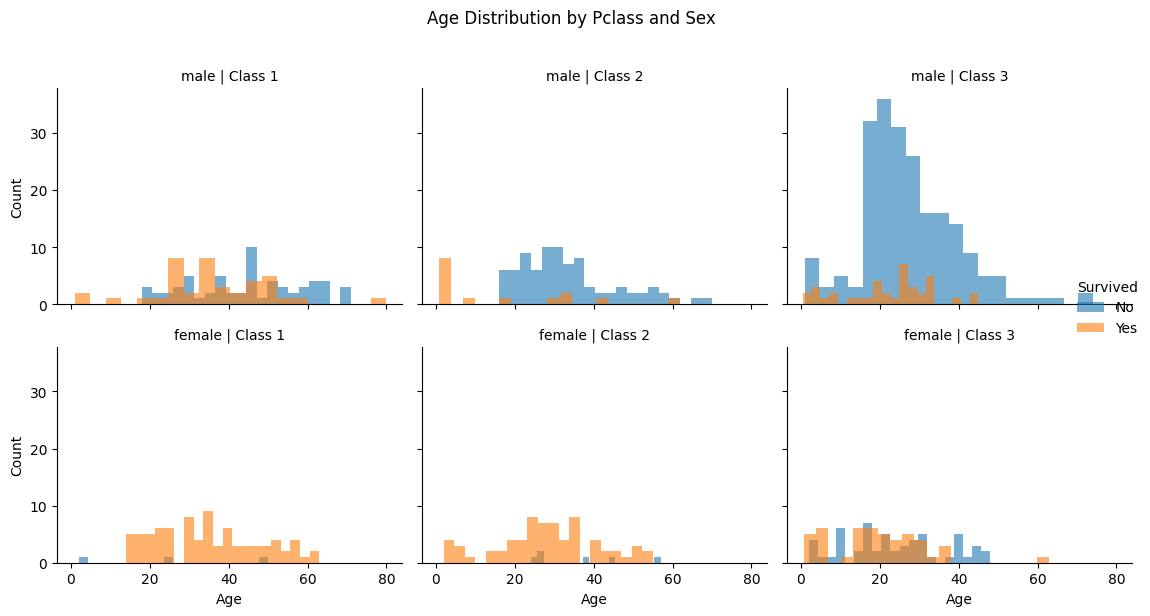

,Model,RMSE
0,Linear Regression,11.9030
1,Decision Tree,14.7973
2,KNN,12.2255


In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# 1. Faceted histogram of age by pclass and sex with survival
g = sns.FacetGrid(df.dropna(subset=['age']), 
                  row='sex', col='pclass',
                  hue='survived',
                  height=3, aspect=1.2,
                  row_order=['male', 'female'],
                  col_order=[1, 2, 3])
g.map(plt.hist, 'age', bins=20, alpha=0.6)

g.add_legend(title='Survived', labels=['No', 'Yes'])
g.set_axis_labels('Age', 'Count')
g.set_titles(row_template='{row_name}', col_template='Class {col_name}')

plt.suptitle('Age Distribution by Pclass and Sex', y=1.02)
plt.tight_layout()
plt.show()

# 2. Restrict to observed age rows
df_age = df_corr.dropna(subset=['age']).copy()

# Use same features minus age
age_features = [f for f in features if f != 'age']
X_age = df_age[age_features]
y_age = df_age['age']

X_age_train, X_age_test, y_age_train, y_age_test = train_test_split(
    X_age, y_age, test_size=0.2, random_state=42
)

# 3. Fit regression models
regressors = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

age_results = []
for name, model in regressors.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ]) if name in ['Linear Regression', 'KNN'] else model
    
    pipe.fit(X_age_train, y_age_train)
    preds = pipe.predict(X_age_test)
    rmse = np.sqrt(mean_squared_error(y_age_test, preds))
    age_results.append({'Model': name, 'RMSE': round(rmse, 4)})

display(pd.DataFrame(age_results))

## Part 3 Step 4: Imputation and Model Comparison

For both `deck` and `age`, select one or more imputation strategies, apply them to
the dataset, and compare model performance **with and without imputation**.

### Instructions

1. For each of `deck` and `age`, choose at least one imputation strategy from the
   following options (or propose a reasonable alternative):
   - Predict the missing value using a trained model  
   - Fill with the **median** or **mean** of the observed values  
   - Fill with a **hard-coded value** (e.g., based on passenger class, or a fixed constant that you can justify)
2. Briefly justify your choice of imputation strategy for each feature.
3. Create two versions of the dataset:
   - one **without imputation** (using the original missing values)
   - one **with imputed values**
4. Using each dataset version, train and evaluate the following classifiers:
   1. Logistic regression  
   2. Decision tree  
   3. k-Nearest Neighbors (KNN)  
   4. Two-layer MLP with width 8  
   5. Random forest  
5. Report and compare the **test accuracy** across models and across dataset versions.
6. Assess whether imputation improves, degrades, or has little effect on performance.

### Discussion Questions

After comparing model performance across the different imputation strategies, answer the following:

- Did any imputation strategy **clearly improve** performance relative to no imputation?
  Did any strategy **hurt** performance?
- Were the performance differences **consistent across models**, or did some models
  benefit while others did not?
- Given that the accuracy differences are small, are they **large enough to be meaningful**,
  or could they plausibly be due to random variation from the train–test split?
- Why might a structured imputation strategy help for `deck` but have little effect—or even
  a negative effect—for `age`?
- In what situations is it preferable to **leave missing values untreated** rather than
  impute them, even if a reasonable imputation strategy is available?


In [148]:
# Deck: logistic regression model from Step 3.2
# Age: median by pclass

df_imputed = df_corr.copy()

# 1. Impute deck using lr_deck model
deck_features_clean = [f for f in features if not f.startswith('deck_')]
X_full = df_corr[deck_features_clean].copy()
X_full = X_full.fillna(X_full.median(numeric_only=True)) # Fill for model prediction for now

mask = df_corr['deck'].isna()
deck_preds = lr_deck.predict(X_full[mask])
deck_preds_letters = le_deck.inverse_transform(deck_preds)
deck_pred_dummies = pd.get_dummies(
    pd.Series(deck_preds_letters, index=df_corr[mask].index).astype(str),
    prefix='deck'
).astype(int)

for col in deck_dummies.columns:
    if col in deck_pred_dummies.columns:
        df_imputed.loc[mask, col] = deck_pred_dummies[col].astype(bool)
    else:
        df_imputed.loc[mask, col] = False

# 2. Impute age using median by pclass
age_medians = df.groupby('pclass')['age'].median()
for pclass, median in age_medians.items():
    mask_age = df_imputed['age'].isna() & (df_imputed['pclass'] == pclass)
    df_imputed.loc[mask_age, 'age'] = median

# Split once on full imputed dataset so both models use same test set
X_all = df_imputed[features]
y_all = df_imputed['survived']
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
test_idx = X_test_all.index
print(f"Test samples: {len(test_idx)}")

def evaluate_models_fixed(X, y, label):
    X_test = X.loc[test_idx].fillna(X.median(numeric_only=True))
    y_test = y.loc[test_idx]
    X_train = X.drop(index=test_idx).dropna()
    y_train = y.loc[X_train.index]
    
    results = []
    for name, model in models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ]) if name in ['Logistic Regression', 'KNN', 'MLP'] else model
        pipe.fit(X_train, y_train)
        acc = pipe.score(X_test, y_test)
        results.append({'Model': name, label: round(acc, 4)})
    return pd.DataFrame(results)

# Baseline - train on non-NaN rows, test on fixed test set
baseline_df = evaluate_models_fixed(
    df_corr[features], df_corr['survived'], 'Baseline Accuracy'
)

# Imputed - train on all rows, test on fixed test set
imputed_df = evaluate_models_fixed(
    df_imputed[features], df_imputed['survived'], 'Imputed Accuracy'
)

# Combine and display
comparison = baseline_df.merge(imputed_df, on='Model')
comparison['Change'] = (
    comparison['Imputed Accuracy'] - comparison['Baseline Accuracy']
).round(4)

display(comparison)

Test samples: 179


,Model,Baseline Accuracy,Imputed Accuracy,Change
0,Logistic Regression,0.8156,0.7989,-0.0167
1,Decision Tree,0.7430,0.7933,0.0503
2,KNN,0.7654,0.7765,0.0111
3,MLP,0.7542,0.8380,0.0838
4,Random Forest,0.7765,0.8324,0.0559
